In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from matplotlib import pyplot as plt
import pyvista as pv
from scipy.interpolate import interp1d
import scipy.signal
from pyfield import PyField
from scipy.spatial.transform import Rotation
from tqdm import tqdm
import util
from functools import partial
from matplotlib.patches import Circle

In [4]:
field = PyField()
field.field_init()

In [5]:
# parameters

fc = 20e6 # transducer center frequency
fbw = 0.5 # transducer fractional bandwidth

r_array = 3.5e-3/3/2 # 3.5 F for Eagle Eye. Not sure if correct

Nelm = 64 # number of elements
elm_to_pitch_ratio = 0.8 # element width to pitch ratio

elm_height = 2e-3 # also not sure of this need to adjust to match elevation focus
r_eleFocus = 5e-3 # make large for no elevational focus, e.g. 1e6

Nsub = 9 # Size of sector image subaperture

# transmit elements in subaperture 
tx_inds = [Nsub//2] # center element
# receive elements in subaperture 
rx_inds = range(Nsub) # all elements
# total number of Ascans will be len(tx_inds)*len(rx_inds)*Nelm

imaging_depth = 5e-3

In [6]:
# derived parameters

pitch = 2 * np.pi * r_array / Nelm
elm_width = pitch * elm_to_pitch_ratio
elm_kerf = pitch - elm_width

In [7]:
fs = 200e6 # field ii sampling rate. this should be high enough to converge the solution
c0 = 1540 # sound speed in the medium m/s
rho0 = 1000 # density kg/m^3

field.set_field('c',c0)
field.set_field('fs',fs)
field.set_field('att',0) # this needs to be updated to blood/tissue. see field ii manual for the definition

In [8]:
t_acc, h_acc = util.define_impulse_resp(fc, fbw, fs)
h_acc_h = np.abs(scipy.signal.hilbert(h_acc))
tx_pulse_delay = t_acc[np.argmax(np.abs(h_acc_h))] # peak of the tx pulse

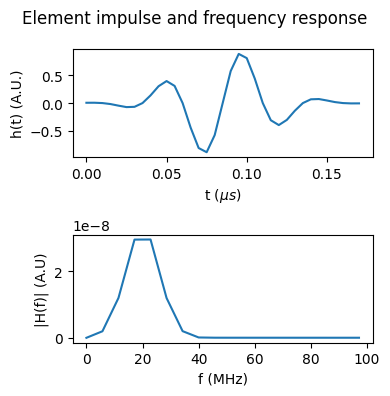

In [9]:
dt = t_acc[1]-t_acc[0]
f = np.fft.rfftfreq(len(t_acc),t_acc[1]-t_acc[0])
h_acc_f = np.fft.rfft(h_acc) * dt

fig, ax = plt.subplots(2,1, figsize=(4,4))
ax[0].plot(t_acc*1e6,h_acc)
ax[0].set_xlabel('t ($\mu s$)')
ax[0].set_ylabel('h(t) (A.U.)')

ax[1].plot(f/1e6,np.abs(h_acc_f))
ax[1].set_xlabel('f (MHz)')
ax[1].set_ylabel('|H(f)| (A.U)')

fig.suptitle('Element impulse and frequency response')

plt.tight_layout()
plt.show()


In [10]:
# excitation signal.
# Dirac delta is used so image is limited by device freq. resp.
excitation = t_acc-t_acc
excitation[0] = 1

In [11]:
Nelm_x = 5 # long exis number of math. elms
Nelm_y = 1 # short exis number of math. elms

Th = field.xdc_convex_focused_array(Nsub, elm_width, elm_height, elm_kerf,
r_array, r_eleFocus, Nelm_y, Nelm_x, [0, 0, 1e6]) # note x and y are flipped due to catheter coord system of x being the cath axis

Th, elm_centers = util.rotate_array(field,Th)

field.xdc_impulse(Th, h_acc)
field.xdc_excitation(Th, excitation)

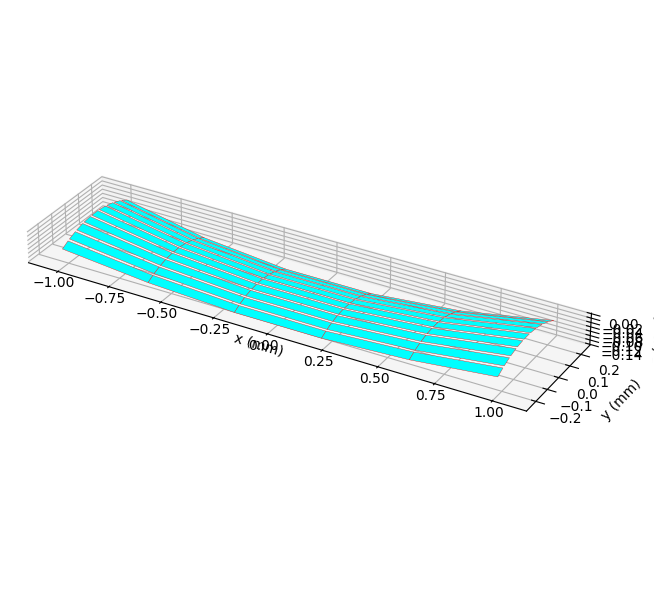

In [12]:
util.show_xducer(field, Th)

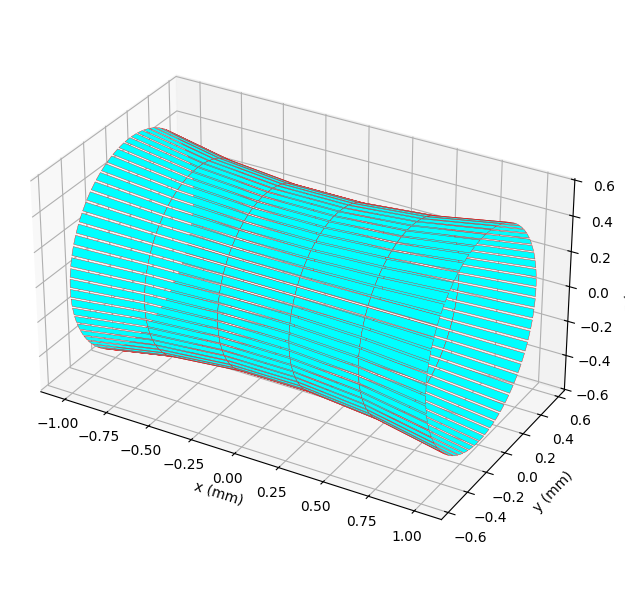

In [13]:
# show full geometry, ignore tangent warnings

Th_plot = field.xdc_convex_focused_array(Nelm, elm_width, elm_height, elm_kerf,
r_array, r_eleFocus, Nelm_y, Nelm_x, [0, 0, 1e6])

Th_plot = util.rotate_and_zOffset_array(field,Th_plot,r_array)

util.show_xducer(field, Th_plot)

In [14]:
dead_r = 200e-6 # the initial dead zone where image is reconstructed beyond this depth + array radius

# Slice is thick as the element size to hand-wavy account for beam spread 
# This should use simulated beam instead width maybe
x_slice_thickness = elm_height

In [ ]:
# load global scatterer map
npz_path = 'vascular_internal_scattererMap.npz'
scatterers_global = np.load(npz_path)['scatterers_global']

In [18]:
# probe position and orientation
# probe coordinate system is defined where its x axis is the catheter axis
# which is also the element rotation axis, and z axis is the transducer normal
# The rotation and translation is defined with respect to the artery model coordinate system

euler_angles_deg = [0,-90,0]
rot = Rotation.from_euler('XYZ', euler_angles_deg, degrees=True)
rotation_mat = rot.as_matrix()

translation_vec = np.array([0,0,1e-2])

# translation_vec = np.array([0.5e-3,0.5e-3,1.7e-2])

In [ ]:

# display the imaging cross-section and rotation axis.
# Note adventitia is modeled as infinite extent in the phantom

mesh_npz_path = 'data/vascular_internal_mesh_combined.npz'
data = np.load(mesh_npz_path)
points = data["points"]
cells = data["cells"]
celltypes = data["celltypes"]
mesh = pv.UnstructuredGrid(cells, celltypes, points)
mesh.cell_data["material_id"] = data["cd::material_id"]

normal = rot.apply([1, 0, 0])  # x axis is the plane normal/rotation axis
sliced_mesh = mesh.slice(normal=normal, origin=translation_vec)

pl = pv.Plotter(off_screen=True)

arrow = pv.Arrow(start=translation_vec, direction=normal, scale=0.005)  # scale adjusts arrow length

pl.add_mesh(mesh, scalars='material_id', show_edges=False, cmap='viridis', opacity=0.3, show_scalar_bar=False)
pl.add_mesh(sliced_mesh, scalars='material_id', show_edges=False, cmap='viridis', opacity=1, show_scalar_bar=False)
pl.add_mesh(arrow, color='gray')

imaging_volume = pv.Cylinder(
        center=translation_vec,
        direction=normal,
        radius=imaging_depth,
        height=x_slice_thickness,
        resolution=100
    )
pl.add_mesh(imaging_volume, color='lightgreen', opacity=0.25)

# pl.show()

img = pl.screenshot(return_img=True)
pl.close()

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img)
ax.set_axis_off()
plt.show()



KeyError: 'cd::material_id is not a file in the archive'

In [ ]:
# sampled scatterer population in xducer coordinate system
scatterers_local = util.mask_scatterers_local(scatterers_global,
                         translation_vec,
                         rotation_mat,
                        x_slice_thickness,
                        imaging_depth)

In [ ]:
x = scatterers_local[:,0]
y = scatterers_local[:,1]
z = scatterers_local[:,2]
reflectivities = scatterers_local[:,3]

fig, ax = plt.subplots(1,2,figsize=(6, 3))
ax[0].scatter(x*1e3, y*1e3, c=reflectivities, cmap='rainbow_r', s=1)
ax[0].set_aspect('equal')
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel('y (mm)')
ax[0].grid()

ax[1].scatter(y*1e3, z*1e3, c=reflectivities, cmap='rainbow_r', s=1)
ax[1].set_aspect('equal')
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel('z (mm)')
ax[1].grid()

fig.suptitle('Scatterer population in xducer coordinate system')

plt.show()

In [ ]:
t_max = 2 * imaging_depth / c0 + (2*np.max(t_acc))
dt = 1/fs
t_int = np.arange(0, t_max+dt, dt) # this is the time vector that's used to interpolate all RF data to same time base

In [ ]:
single_tx_view_angle = np.pi/2

In [ ]:
# imaging grid for single sector

f0 = 40e6
lambda0 = c0/f0
dr = lambda0/2
dtheta = np.deg2rad(1)

r_range = np.arange(dead_r+r_array, imaging_depth+dr, dr)
theta_range = np.arange(-single_tx_view_angle/2, single_tx_view_angle/2+dtheta, dtheta)

theta_grid, r_grid = np.meshgrid(theta_range,r_range)
theta_grid = np.atleast_2d(np.ravel(theta_grid)).T
r_grid = np.atleast_2d(np.ravel(r_grid)).T

x_grid = np.zeros_like(r_grid)
y_grid = r_grid * np.sin(theta_grid)

z_grid = r_grid * np.cos(theta_grid)

im_grid = x_grid - x_grid + 0j

z_grid = z_grid - r_array

pixel_coords = np.concatenate((x_grid,y_grid,z_grid),axis=1)

In [ ]:
# collect syntetic aperture image moving the imaging subaperture for each element

dtheta_array_deg = 360/Nelm

tx_event_thetas = []
ims = []
for theta_deg in tqdm(np.arange(0, 360, dtheta_array_deg)):

    angles = [theta_deg, 0, 0]
    
    rot = Rotation.from_euler('xyz', angles, degrees=True)
    rotated_xyz = rot.apply(scatterers_local[:, :3])
    scatterers = np.column_stack((rotated_xyz, scatterers_local[:, 3]))
    
    scatterers_frame = [s for s in scatterers if (np.abs(s[0])<=x_slice_thickness) & (np.abs(s[1])<=10*r_array) & (s[2]>dead_r+r_array)]
    scatterers_frame = np.array(scatterers_frame)
    
    
    if len(scatterers_frame)>0:

        scatterers_frame[:,2] = scatterers_frame[:,2] - r_array
    
        [RFdata, t0] = field.calc_scat_all(Th, Th,  scatterers_frame[:,:3], scatterers_frame[:,3], dec_factor=1)
        t = np.arange(len(RFdata)) / fs + t0

        # diffraction correction as a function of depth
        RFdata = RFdata * t[:,np.newaxis]
        
        intfun = interp1d(t, RFdata, axis=0, bounds_error=False, fill_value=0)
        RFdata_int = intfun(t_int)

        
        N = len(elm_centers)
        RFdata_2D = np.zeros((np.shape(RFdata)[0], N, N))
        
        for tx_ind in range(N):
            for rx_ind in range(N):
                RFdata_2D[:, tx_ind, rx_ind] = RFdata[:, tx_ind * N + rx_ind]


        pix_vals = util.recon_img(RFdata_2D, elm_centers, pixel_coords, tx_pulse_delay, tx_inds, rx_inds, c0, t)
    
        im_vec = np.zeros((len(theta_range)*len(r_range),), dtype=complex)
        for job_ind in range(np.shape(pix_vals)[0]): 
            im_vec += pix_vals[job_ind]
        im = np.reshape(im_vec, (len(theta_range),len(r_range)),order='F')
            
    else:
    
        im = np.zeros(shape=(len(theta_range),len(r_range)))
        
    ims.append(im)
    tx_event_thetas.append(np.deg2rad(theta_deg))

ims = np.array(ims)
tx_event_thetas = np.array(tx_event_thetas)

In [ ]:
# interpolate individual sector images to the global image 0-2pi

dtheta_range_global = np.deg2rad(1)
theta_range_global = np.arange(0, 4*np.pi,dtheta_range_global)

im_global = np.zeros(shape=(len(theta_range_global),len(r_range)),dtype=complex)

for im_ind in range(len(tx_event_thetas)):
    
    theta_local_global = np.mod(theta_range + tx_event_thetas[im_ind], 2*np.pi)

    theta_local_global = np.unwrap(theta_local_global)

    intfun = interp1d(theta_local_global, ims[im_ind], axis=0,
                 kind='linear', bounds_error=False, fill_value=0)
    im_global += intfun(theta_range_global)

theta_range_global = np.arange(0, 2*np.pi,dtheta_range_global)
im_global = im_global[:np.shape(im_global)[0]//2,:] + im_global[np.shape(im_global)[0]//2:,:]

In [ ]:
im_plot = np.abs(im_global)

im_plot_dB = 20*np.log10(np.abs(im_plot))
im_plot_dB = im_plot_dB - np.max(im_plot_dB)

im_plot_dB[im_plot==0] = -300


In [ ]:
dB_range = 40

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.grid(0)
surf = ax.pcolormesh((r_range)*1e3, np.rad2deg(theta_range_global), im_plot_dB,cmap='gray',vmin=-dB_range,vmax=0)
# ax.set_aspect('equal')
ax.set_ylabel(r'$theta$ (deg)')
ax.set_xlabel('r (mm)')

plt.show()

In [ ]:
cart_img, cart_x, cart_y = util.polar_to_cartesian(im_plot_dB, np.min(r_grid), np.max(r_grid), dtheta_range_global)

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(16, 6))

ax[0].scatter(scatterers_local[:,1]*1e3, scatterers_local[:,2]*1e3, c=scatterers_local[:,3],s=1)
ax[0].set_aspect('equal')
ax[0].set_xlabel('y (mm)')
ax[0].set_ylabel('z (mm)')
ax[0].set_aspect(1)
# ax[0].grid()
ax[0].set_xlim(-5,5)
ax[0].set_ylim(-5,5)
ax[0].set_facecolor('k')
ax[0].set_title('Scatterer phantom', fontsize=16)

circle = Circle((0, 0), r_array*1e3, color='yellow', alpha=0.5)
ax[0].add_patch(circle)


ax[1].pcolormesh(cart_y*1e3, cart_x*1e3, cart_img.T, cmap='gray', vmin=-dB_range, vmax=0)
ax[1].set_aspect('equal')
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel('x (mm)')
ax[1].set_title('Simulated IVUS Image', fontsize=16)
ax[1].set_xlim(-5,5)
ax[1].set_ylim(-5,5)
# ax[1].grid()
ax[1].set_facecolor('k')

ax[2].grid(0)
surf = ax[2].pcolormesh((r_range)*1e3, np.rad2deg(theta_range_global), im_plot_dB,cmap='gray',vmin=-dB_range,vmax=0)
# ax[2].set_aspect(0.05)
ax[2].set_ylabel(r'$\theta$ (deg)')
ax[2].set_xlabel('r (mm)')
ax[2].set_title('Simulated IVUS Image', fontsize=16)

plt.tight_layout()


plt.show()